# Advanced Dialogue Summarization Using Transformer Architectures

**Dataset:** `knkarthick/samsum` from Hugging Face  
**Architecture:** BERT encoder + GPT-2 decoder using Hugging Face `EncoderDecoderModel`

This revised notebook aligns with the finalized project pitch by implementing a complete proof of concept for transformer-based dialogue summarization. It focuses on reducing information overload, improving communication efficiency, and demonstrating a reproducible machine learning engineering workflow.

## Required Notebook Structure

1. Dataset Exploration and Preparation  
2. Model Architecture Implementation  
3. Training and Optimization  
4. Evaluation and Error Analysis  
5. Documentation and Presentation

# 1. Dataset Exploration and Preparation

This section loads the SAMSum dataset, explores the train, validation, and test splits, performs detailed EDA, creates representative stratified subsets, and prepares the data for transformer training.

In [1]:
# ============================================================
# 1. DATASET EXPLORATION AND PREPARATION
# ============================================================

import os
import re
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset, Dataset

from transformers import (
    BertTokenizerFast,
    GPT2TokenizerFast,
    EncoderDecoderModel,
    DataCollatorForSeq2Seq,
    get_linear_schedule_with_warmup
)

try:
    from torch.optim import AdamW
except ImportError:
    from transformers import AdamW

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path("dialogue_summarization_outputs")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
FIGURE_DIR = PROJECT_DIR / "figures"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"

for directory in [PROJECT_DIR, ARTIFACT_DIR, FIGURE_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available. The notebook can run on CPU, but training will be slower.")

Using device: cpu
GPU not available. The notebook can run on CPU, but training will be slower.


## Dataset Loading

The SAMSum dataset contains realistic messenger-style dialogues paired with human-written summaries. Loading all three splits supports a more rigorous train, validation, and test workflow.

In [2]:
dataset = load_dataset("knkarthick/samsum")

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print("Dataset split sizes:")
print({
    "train": len(train_df),
    "validation": len(val_df),
    "test": len(test_df)
})

display(train_df.head())

Dataset split sizes:
{'train': 14731, 'validation': 818, 'test': 819}


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


## Exploratory Data Analysis

The finalized pitch emphasizes dialogue complexity, conversational variability, compression ratios, vocabulary behavior, and multi-speaker interaction patterns. The following cells create those features and save visual and tabular artifacts for later review.

In [3]:
def normalize_whitespace(text):
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def count_words(text):
    return len(normalize_whitespace(text).split())

def extract_speakers(dialogue):
    speaker_matches = re.findall(r"(^|\n)([A-Za-z][A-Za-z0-9_ .'-]{0,30}):", str(dialogue))
    return sorted(set(match[1].strip() for match in speaker_matches))

def add_dialogue_features(df, split_name):
    df = df.copy()
    df["split"] = split_name
    df["dialogue_clean"] = df["dialogue"].apply(normalize_whitespace)
    df["summary_clean"] = df["summary"].apply(normalize_whitespace)
    df["dialogue_word_count"] = df["dialogue_clean"].apply(count_words)
    df["summary_word_count"] = df["summary_clean"].apply(count_words)
    df["compression_ratio"] = df["summary_word_count"] / df["dialogue_word_count"].replace(0, np.nan)
    df["speaker_list"] = df["dialogue"].apply(extract_speakers)
    df["speaker_count"] = df["speaker_list"].apply(len)
    df["turn_count"] = df["dialogue"].apply(lambda x: len([line for line in str(x).splitlines() if line.strip()]))
    return df

train_eda = add_dialogue_features(train_df, "train")
val_eda = add_dialogue_features(val_df, "validation")
test_eda = add_dialogue_features(test_df, "test")
all_eda = pd.concat([train_eda, val_eda, test_eda], ignore_index=True)

eda_stats = all_eda.groupby("split")[
    ["dialogue_word_count", "summary_word_count", "compression_ratio", "speaker_count", "turn_count"]
].describe().round(2)

eda_stats.to_csv(ARTIFACT_DIR / "eda_summary_statistics.csv")
display(eda_stats)

dialogue_word_count                                                \
                         count   mean    std   min   25%   50%    75%    max   
split                                                                          
test                     819.0  95.51  75.23   9.0  42.0  74.0  126.0  516.0   
train                  14731.0  93.79  74.03   7.0  39.0  73.0  128.0  803.0   
validation               818.0  91.64  74.48  10.0  38.0  70.0  127.0  540.0   

           summary_word_count         ... speaker_count       turn_count  \
                        count   mean  ...           75%   max      count   
split                                 ...                                  
test                    819.0  20.02  ...           2.0  11.0      819.0   
train                 14731.0  20.32  ...           3.0  14.0    14731.0   
validation              818.0  20.28  ...           3.0  12.0      818.0   

                                                     
             mean   std  min  25%   50%   75%   max  
split                                                
test        11.25  6.35  3.0  6.0  10.0  15.0  30.0  
train       11.17  6.45  3.0  6.0  10.0  15.0  46.0  
validation  10.83  6.38  3.0  6.0   9.0  14.0  30.0  

[3 rows x 40 columns]

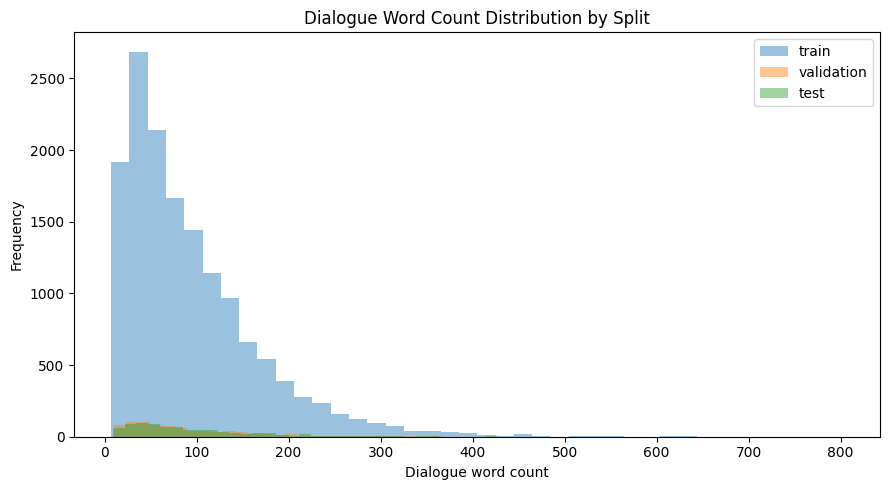

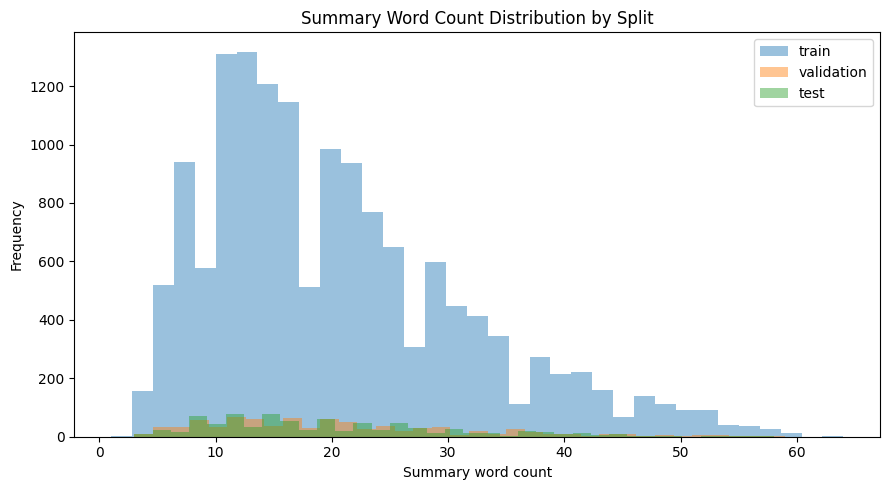

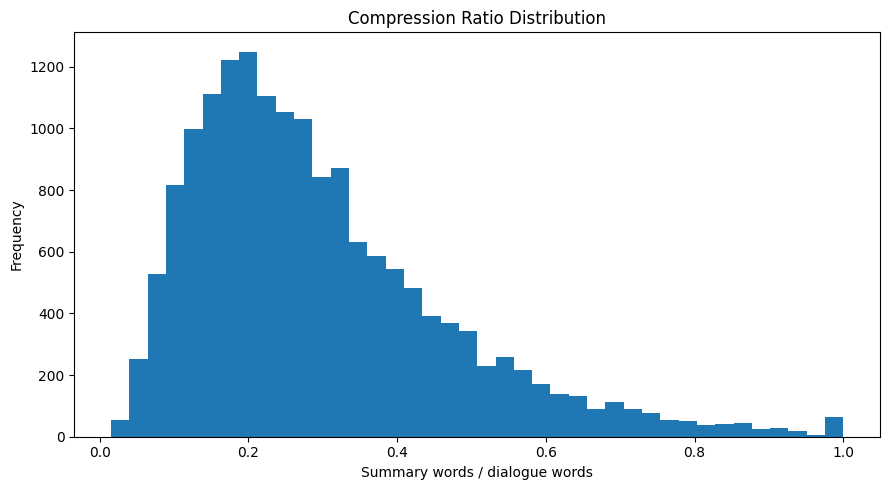

In [4]:
# Histograms
plt.figure(figsize=(9, 5))
for split_name, frame in [("train", train_eda), ("validation", val_eda), ("test", test_eda)]:
    plt.hist(frame["dialogue_word_count"], bins=40, alpha=0.45, label=split_name)
plt.title("Dialogue Word Count Distribution by Split")
plt.xlabel("Dialogue word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dialogue_word_count_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
for split_name, frame in [("train", train_eda), ("validation", val_eda), ("test", test_eda)]:
    plt.hist(frame["summary_word_count"], bins=35, alpha=0.45, label=split_name)
plt.title("Summary Word Count Distribution by Split")
plt.xlabel("Summary word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "summary_word_count_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(all_eda["compression_ratio"].clip(upper=1), bins=40)
plt.title("Compression Ratio Distribution")
plt.xlabel("Summary words / dialogue words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compression_ratio_distribution.png", dpi=150)
plt.show()

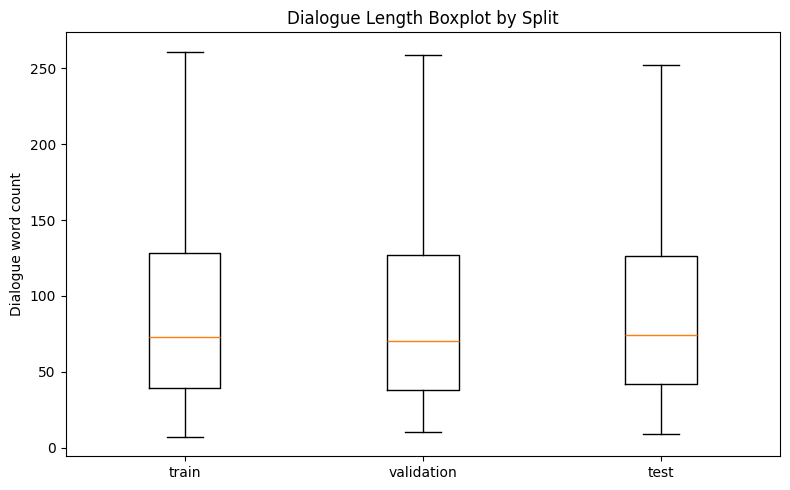

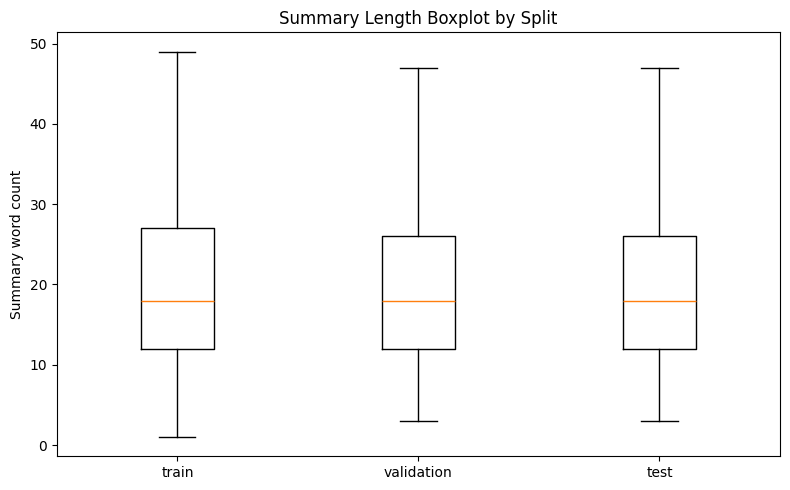

In [5]:
# Boxplots
plt.figure(figsize=(8, 5))
plt.boxplot(
    [train_eda["dialogue_word_count"], val_eda["dialogue_word_count"], test_eda["dialogue_word_count"]],
    labels=["train", "validation", "test"],
    showfliers=False
)
plt.title("Dialogue Length Boxplot by Split")
plt.ylabel("Dialogue word count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dialogue_length_boxplot.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(
    [train_eda["summary_word_count"], val_eda["summary_word_count"], test_eda["summary_word_count"]],
    labels=["train", "validation", "test"],
    showfliers=False
)
plt.title("Summary Length Boxplot by Split")
plt.ylabel("Summary word count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "summary_length_boxplot.png", dpi=150)
plt.show()

,dialogue_word_count,summary_word_count,compression_ratio,speaker_count,turn_count
dialogue_word_count,1.000,0.604,-0.573,0.056,0.823
summary_word_count,0.604,1.000,-0.022,0.037,0.537
compression_ratio,-0.573,-0.022,1.000,-0.033,-0.581
speaker_count,0.056,0.037,-0.033,1.000,0.055
turn_count,0.823,0.537,-0.581,0.055,1.000


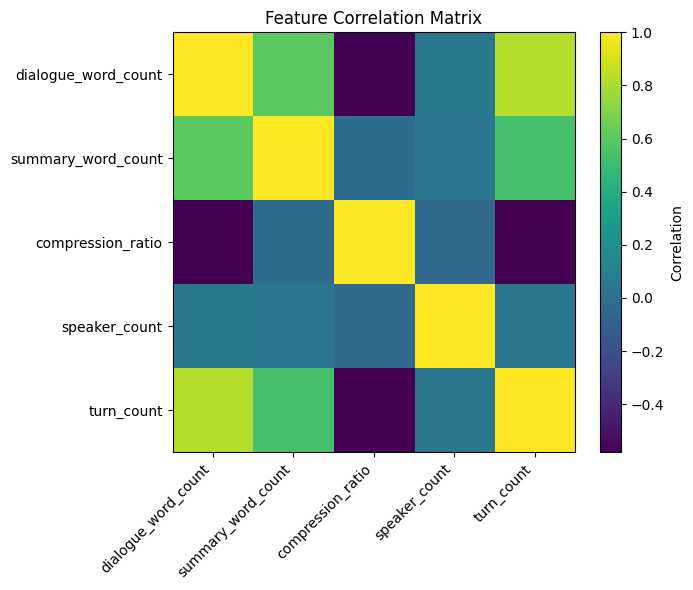

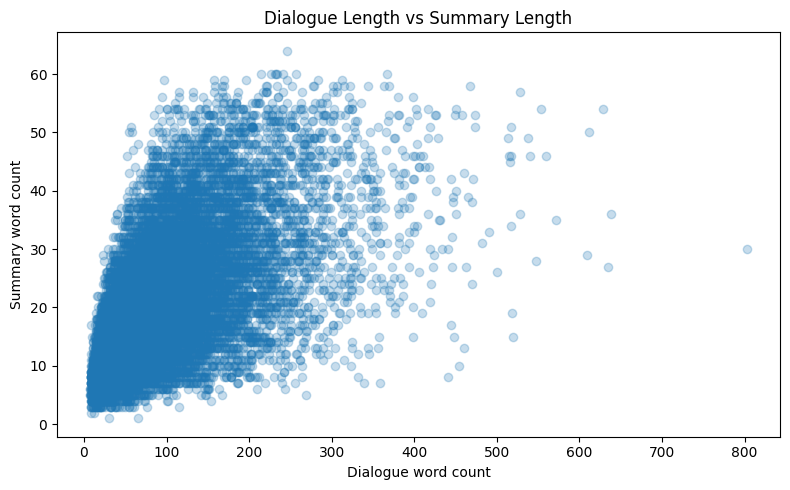

In [6]:
# Correlation visualization
corr_cols = ["dialogue_word_count", "summary_word_count", "compression_ratio", "speaker_count", "turn_count"]
corr_matrix = all_eda[corr_cols].corr().round(3)
corr_matrix.to_csv(ARTIFACT_DIR / "eda_correlation_matrix.csv")
display(corr_matrix)

plt.figure(figsize=(7, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_correlation_matrix.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(all_eda["dialogue_word_count"], all_eda["summary_word_count"], alpha=0.25)
plt.title("Dialogue Length vs Summary Length")
plt.xlabel("Dialogue word count")
plt.ylabel("Summary word count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dialogue_vs_summary_length_scatter.png", dpi=150)
plt.show()

In [7]:
# Vocabulary characteristics
def vocabulary_profile(text_series, top_n=20):
    tokens = []
    for text in text_series:
        tokens.extend(re.findall(r"\b[a-zA-Z']+\b", str(text).lower()))
    counts = Counter(tokens)
    total_tokens = sum(counts.values())
    unique_tokens = len(counts)
    top_terms = pd.DataFrame(counts.most_common(top_n), columns=["token", "frequency"])
    return total_tokens, unique_tokens, unique_tokens / max(total_tokens, 1), top_terms

dialogue_total, dialogue_unique, dialogue_ttr, dialogue_top = vocabulary_profile(train_eda["dialogue_clean"])
summary_total, summary_unique, summary_ttr, summary_top = vocabulary_profile(train_eda["summary_clean"])

vocab_stats = pd.DataFrame([
    {"text_type": "dialogue", "total_tokens": dialogue_total, "unique_tokens": dialogue_unique, "type_token_ratio": dialogue_ttr},
    {"text_type": "summary", "total_tokens": summary_total, "unique_tokens": summary_unique, "type_token_ratio": summary_ttr},
])

vocab_stats.to_csv(ARTIFACT_DIR / "vocabulary_statistics.csv", index=False)
dialogue_top.to_csv(ARTIFACT_DIR / "top_dialogue_terms.csv", index=False)
summary_top.to_csv(ARTIFACT_DIR / "top_summary_terms.csv", index=False)

display(vocab_stats)
display(dialogue_top)
display(summary_top)

,text_type,total_tokens,unique_tokens,type_token_ratio
0,dialogue,1359297,28921,0.021276
1,summary,295509,16894,0.057169


,token,frequency
0,i,45698
1,you,39465
2,the,31583
3,to,29226
4,a,22341
5,it,21178
6,and,17752
7,for,11989
8,in,11600
9,is,11342


,token,frequency
0,to,11618
1,the,10756
2,and,10146
3,a,7478
4,is,6850
5,will,6743
6,for,4678
7,in,4172
8,at,3715
9,her,3609


,speaker_count,conversation_count
0,1,14
1,2,11984
2,3,3075
3,4,918
4,5,211
5,6,85
6,7,33
7,8,15
8,9,14
9,10,6


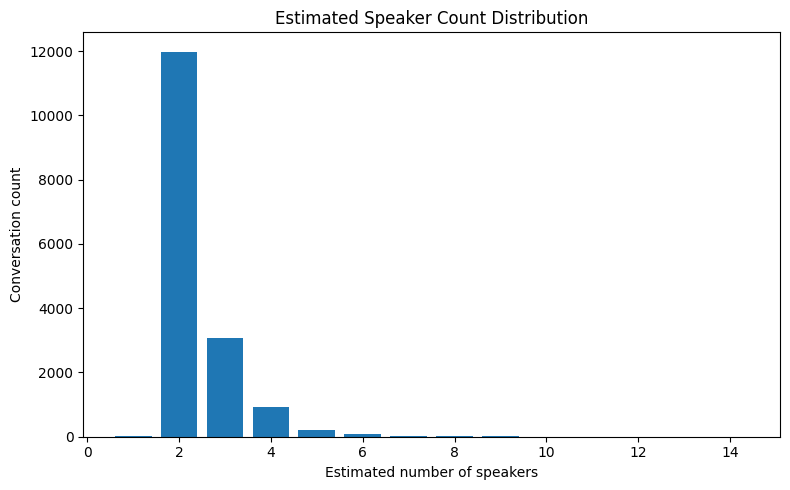

In [8]:
# Multi-speaker patterns
speaker_stats = all_eda.groupby("speaker_count").size().reset_index(name="conversation_count")
speaker_stats.to_csv(ARTIFACT_DIR / "speaker_count_distribution.csv", index=False)
display(speaker_stats)

plt.figure(figsize=(8, 5))
plt.bar(speaker_stats["speaker_count"], speaker_stats["conversation_count"])
plt.title("Estimated Speaker Count Distribution")
plt.xlabel("Estimated number of speakers")
plt.ylabel("Conversation count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "speaker_count_distribution.png", dpi=150)
plt.show()

## Representative Stratified Sampling

The project pitch calls for representative sampling instead of simple random sampling. This notebook samples by combined dialogue-length and summary-length strata to preserve short, medium, and long examples across the train, validation, and test splits.

Required minimum subset sizes are implemented:

- 3,000 training samples
- 500 validation samples
- 500 testing samples

In [9]:
def stratified_length_sample(df, target_n, split_name, seed=SEED, q=8):
    working = df.copy()
    working["dialogue_bin"] = pd.qcut(working["dialogue_word_count"], q=q, duplicates="drop")
    working["summary_bin"] = pd.qcut(working["summary_word_count"], q=q, duplicates="drop")
    working["stratum"] = working["dialogue_bin"].astype(str) + " | " + working["summary_bin"].astype(str)

    stratum_counts = working["stratum"].value_counts()
    allocations = (stratum_counts / len(working) * target_n).round().astype(int).clip(lower=1)

    sampled_parts = []
    for stratum, n_allocated in allocations.items():
        group = working[working["stratum"] == stratum]
        n_take = min(len(group), int(n_allocated))
        if n_take > 0:
            sampled_parts.append(group.sample(n=n_take, random_state=seed))

    sampled = pd.concat(sampled_parts, ignore_index=True)

    if len(sampled) > target_n:
        sampled = sampled.sample(n=target_n, random_state=seed)
    elif len(sampled) < min(target_n, len(working)):
        needed = min(target_n - len(sampled), len(working) - len(sampled))
        used_ids = set(sampled["id"]) if "id" in sampled.columns else set()
        remaining = working[~working.get("id", pd.Series(index=working.index, dtype=object)).isin(used_ids)] if "id" in working.columns else working.drop(sampled.index, errors="ignore")
        if needed > 0 and len(remaining) > 0:
            sampled = pd.concat([sampled, remaining.sample(n=needed, random_state=seed)], ignore_index=True)

    sampled["subset_split"] = split_name
    return sampled.reset_index(drop=True)

train_subset = stratified_length_sample(train_eda, target_n=3000, split_name="train")
val_subset = stratified_length_sample(val_eda, target_n=500, split_name="validation")
test_subset = stratified_length_sample(test_eda, target_n=500, split_name="test")

print({
    "train_subset": len(train_subset),
    "validation_subset": len(val_subset),
    "test_subset": len(test_subset)
})

train_subset[["dialogue", "summary"]].to_csv(ARTIFACT_DIR / "train_representative_subset.csv", index=False)
val_subset[["dialogue", "summary"]].to_csv(ARTIFACT_DIR / "validation_representative_subset.csv", index=False)
test_subset[["dialogue", "summary"]].to_csv(ARTIFACT_DIR / "test_representative_subset.csv", index=False)

{'train_subset': 3000, 'validation_subset': 500, 'test_subset': 500}


In [10]:
def compare_full_vs_subset(full_df, subset_df, split_name):
    return pd.DataFrame({
        "dataset": [f"{split_name}_full", f"{split_name}_subset"],
        "n": [len(full_df), len(subset_df)],
        "dialogue_words_mean": [full_df["dialogue_word_count"].mean(), subset_df["dialogue_word_count"].mean()],
        "dialogue_words_median": [full_df["dialogue_word_count"].median(), subset_df["dialogue_word_count"].median()],
        "summary_words_mean": [full_df["summary_word_count"].mean(), subset_df["summary_word_count"].mean()],
        "summary_words_median": [full_df["summary_word_count"].median(), subset_df["summary_word_count"].median()],
        "compression_ratio_mean": [full_df["compression_ratio"].mean(), subset_df["compression_ratio"].mean()],
        "speaker_count_mean": [full_df["speaker_count"].mean(), subset_df["speaker_count"].mean()]
    })

representativeness_table = pd.concat([
    compare_full_vs_subset(train_eda, train_subset, "train"),
    compare_full_vs_subset(val_eda, val_subset, "validation"),
    compare_full_vs_subset(test_eda, test_subset, "test")
], ignore_index=True).round(3)

representativeness_table.to_csv(ARTIFACT_DIR / "representativeness_summary.csv", index=False)
display(representativeness_table)

,dataset,n,dialogue_words_mean,dialogue_words_median,summary_words_mean,summary_words_median,compression_ratio_mean,speaker_count_mean
0,train_full,14731,93.793,73.0,20.318,18.0,0.296,2.393
1,train_subset,3000,93.662,73.0,20.305,18.0,0.297,2.417
2,validation_full,818,91.642,70.0,20.284,18.0,0.301,2.386
3,validation_subset,500,91.080,69.0,20.298,18.0,0.305,2.382
4,test_full,819,95.508,74.0,20.017,18.0,0.290,2.359
5,test_subset,500,95.324,74.0,20.058,18.0,0.291,2.362


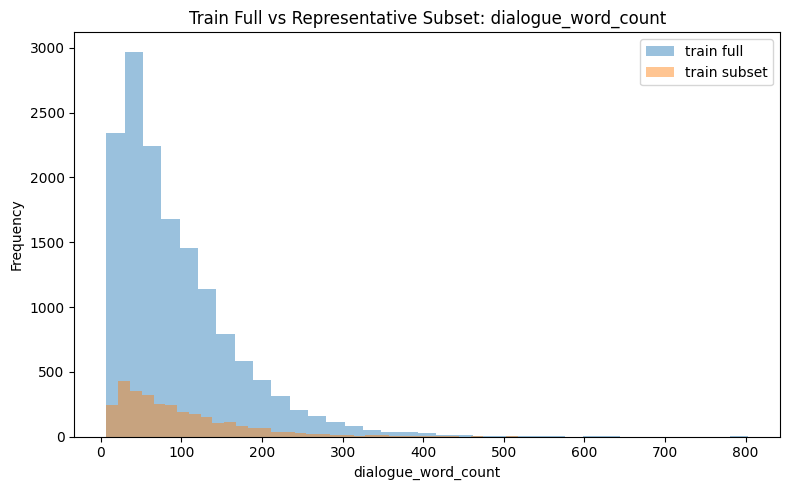

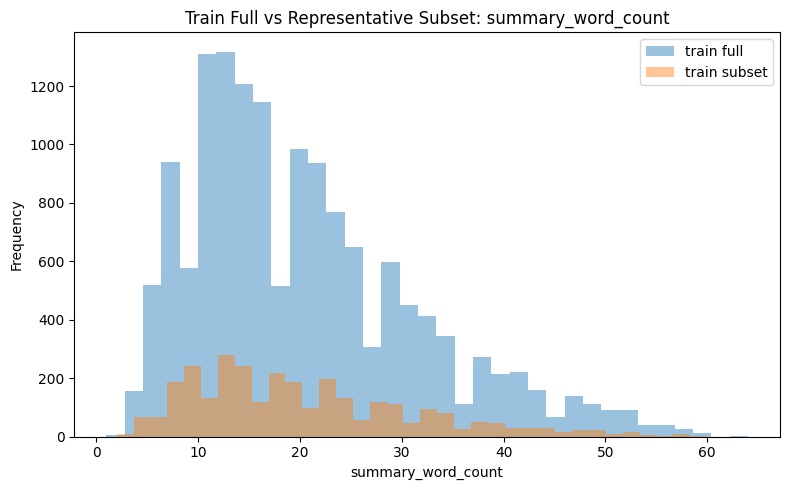

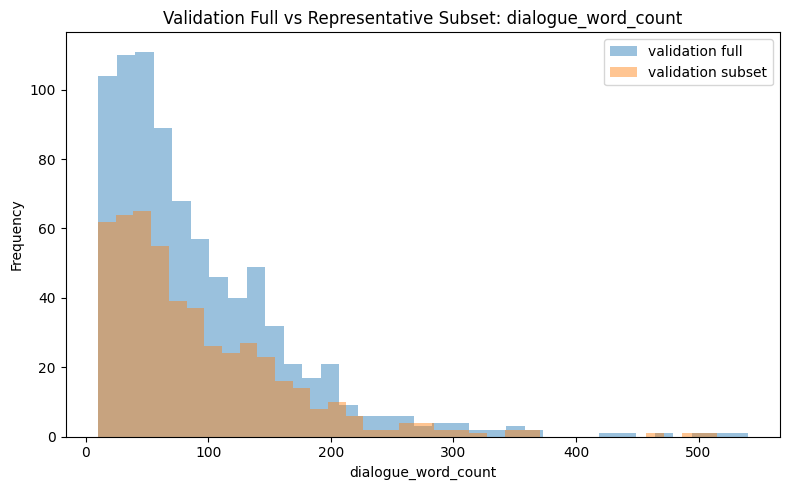

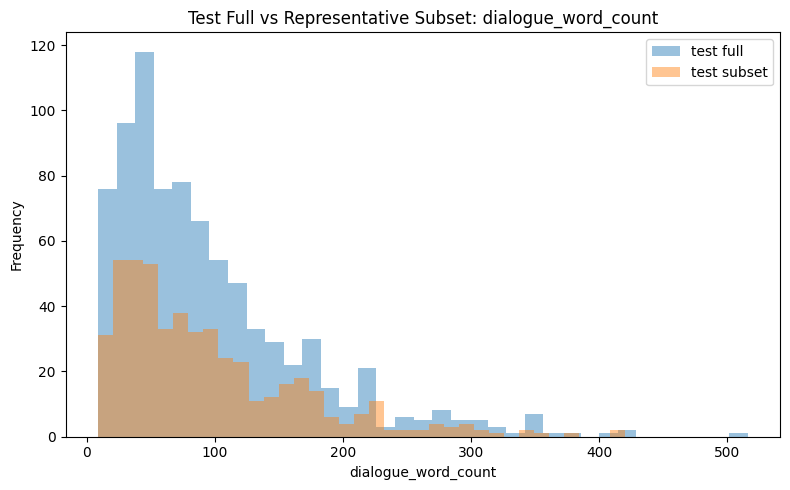

In [11]:
def plot_full_subset_distribution(full_df, subset_df, column, split_name, filename):
    plt.figure(figsize=(8, 5))
    plt.hist(full_df[column], bins=35, alpha=0.45, label=f"{split_name} full")
    plt.hist(subset_df[column], bins=35, alpha=0.45, label=f"{split_name} subset")
    plt.title(f"{split_name.title()} Full vs Representative Subset: {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=150)
    plt.show()

plot_full_subset_distribution(train_eda, train_subset, "dialogue_word_count", "train", "train_full_vs_subset_dialogue_words.png")
plot_full_subset_distribution(train_eda, train_subset, "summary_word_count", "train", "train_full_vs_subset_summary_words.png")
plot_full_subset_distribution(val_eda, val_subset, "dialogue_word_count", "validation", "validation_full_vs_subset_dialogue_words.png")
plot_full_subset_distribution(test_eda, test_subset, "dialogue_word_count", "test", "test_full_vs_subset_dialogue_words.png")

## Data Preprocessing

This workflow implements dialogue cleaning, whitespace normalization, tokenization, truncation handling, dynamic padding, PyTorch datasets, DataLoaders, and batch processing.

In [12]:
def clean_dialogue(text):
    text = str(text).replace("\r", "\n")
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

def clean_summary(text):
    return re.sub(r"\s+", " ", str(text)).strip()

for frame in [train_subset, val_subset, test_subset]:
    frame["dialogue_prepared"] = frame["dialogue"].apply(clean_dialogue)
    frame["summary_prepared"] = frame["summary"].apply(clean_summary)

train_hf = Dataset.from_pandas(train_subset[["dialogue_prepared", "summary_prepared"]])
val_hf = Dataset.from_pandas(val_subset[["dialogue_prepared", "summary_prepared"]])
test_hf = Dataset.from_pandas(test_subset[["dialogue_prepared", "summary_prepared"]])

print(train_hf)

Dataset({
    features: ['dialogue_prepared', 'summary_prepared'],
    num_rows: 3000
})


## 💡 Insight Summary

This section established the data foundation for the proof of concept. The SAMSum dataset was loaded across train, validation, and test splits, then analyzed through dialogue length, summary length, compression ratio, vocabulary, and speaker-pattern features. Representative sampling matters because it preserves the structure of the broader dataset while keeping the experiment computationally manageable. From a business perspective, this improves confidence that results are not limited to unusually simple conversations. From a technical perspective, it reduces sampling bias and creates a stronger basis for model evaluation.

# 2. Model Architecture Implementation

This section implements the transformer architecture described in the finalized pitch: a BERT encoder paired with a GPT-2 decoder using Hugging Face's `EncoderDecoderModel`.

In [13]:
# ============================================================
# 2. MODEL ARCHITECTURE IMPLEMENTATION
# ============================================================

encoder_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
decoder_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

# GPT-2 does not include a padding token by default.
decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

ENCODER_MAX_LENGTH = 256
DECODER_MAX_LENGTH = 64

def tokenize_batch(batch):
    model_inputs = encoder_tokenizer(
        batch["dialogue_prepared"],
        max_length=ENCODER_MAX_LENGTH,
        truncation=True,
        padding=False
    )

    labels = decoder_tokenizer(
        batch["summary_prepared"],
        max_length=DECODER_MAX_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_hf.map(tokenize_batch, batched=True, remove_columns=train_hf.column_names)
tokenized_val = val_hf.map(tokenize_batch, batched=True, remove_columns=val_hf.column_names)
tokenized_test = test_hf.map(tokenize_batch, batched=True, remove_columns=test_hf.column_names)

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [19]:
model = EncoderDecoderModel.from_encoder_decoder_pretrained(
    "bert-base-uncased",
    "gpt2"
)

model.config.decoder_start_token_id = decoder_tokenizer.bos_token_id or decoder_tokenizer.eos_token_id
model.config.pad_token_id = decoder_tokenizer.pad_token_id
model.config.eos_token_id = decoder_tokenizer.eos_token_id
model.config.vocab_size = model.config.decoder.vocab_size

model.config.decoder.is_decoder = True
model.config.decoder.add_cross_attention = True

model.generation_config.max_length = DECODER_MAX_LENGTH
model.generation_config.min_length = 8
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.early_stopping = True
model.generation_config.num_beams = 4
model.generation_config.length_penalty = 1.2

model.to(DEVICE)

print("Encoder-decoder model initialized.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: gpt2
Key                                                 | Status  | 
----------------------------------------------------+---------+-
transformer.h.{0...11}.crossattention.q_attn.bias   | MISSING | 
transformer.h.{0...11}.crossattention.q_attn.weight | MISSING | 
transformer.h.{0...11}.crossattention.c_proj.bias   | MISSING | 
transformer.h.{0...11}.ln_cross_attn.bias           | MISSING | 
transformer.h.{0...11}.ln_cross_attn.weight         | MISSING | 
transformer.h.{0...11}.crossattention.c_proj.weight | MISSING | 
transformer.h.{0...11}.crossattention.c_attn.bias   | MISSING | 
transformer.h.{0...11}.crossattention.c_attn.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encoder-decoder model initialized.


In [15]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=encoder_tokenizer,
    model=model,
    padding=True
)

BATCH_SIZE = 4 if torch.cuda.is_available() else 2

train_loader = DataLoader(tokenized_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(tokenized_val, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader = DataLoader(tokenized_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 2
Train batches: 1500
Validation batches: 250
Test batches: 250


## Architecture Explanation

Sequence-to-sequence learning converts an input sequence into an output sequence. In this project, the input is a multi-speaker dialogue and the output is a concise summary.

The encoder reads the full dialogue and produces contextual representations. BERT is useful here because its bidirectional attention helps it understand relationships across the conversation. The decoder generates the summary one token at a time. GPT-2 is useful for this role because it is designed for fluent auto-regressive text generation. Cross-attention connects the two components so the decoder can reference the encoded dialogue while generating each summary token.

Teacher forcing is used during training because the decoder receives the correct previous target tokens when learning to predict the next token. At inference time, the model uses beam search to explore multiple candidate summaries and select a stronger generated sequence.

## 💡 Insight Summary

This section implemented the architecture proposed in the pitch. The BERT encoder supports conversational understanding, while the GPT-2 decoder supports fluent generation. Cross-attention allows the model to connect encoded dialogue context to each generated summary token. The main technical implication is that this architecture is more expressive than a simple baseline, but also more computationally demanding. The business implication is that improved coherence and contextual preservation can make summaries more useful in real operational communication settings.

# 3. Training and Optimization

This section implements AdamW optimization, linear learning rate scheduling, validation loss tracking, gradient clipping, checkpointing, early stopping, and mixed precision training when GPU resources are available.

In [16]:
# ============================================================
# 3. TRAINING AND OPTIMIZATION
# ============================================================

EPOCHS = 3
LEARNING_RATE = 5e-5
GRADIENT_CLIP_NORM = 1.0
PATIENCE = 2

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_training_steps = EPOCHS * len(train_loader)
warmup_steps = int(0.05 * total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print({
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "total_training_steps": total_training_steps,
    "warmup_steps": warmup_steps,
    "mixed_precision": use_amp
})

{'epochs': 3, 'learning_rate': 5e-05, 'total_training_steps': 4500, 'warmup_steps': 225, 'mixed_precision': False}


In [17]:
def train_one_epoch(model, dataloader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0.0
    start_time = time.time()

    for step, batch in enumerate(dataloader, start=1):
        batch = {key: value.to(device) for key, value in batch.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(**batch)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        if step % 50 == 0:
            print(f"Step {step:>4}/{len(dataloader)} | Training loss: {loss.item():.4f}")

    avg_loss = total_loss / max(len(dataloader), 1)
    elapsed = time.time() - start_time
    return avg_loss, elapsed


@torch.no_grad()
def evaluate_loss(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    start_time = time.time()

    for batch in dataloader:
        batch = {key: value.to(device) for key, value in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()

    avg_loss = total_loss / max(len(dataloader), 1)
    elapsed = time.time() - start_time
    return avg_loss, elapsed

In [20]:
training_history = []
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_time = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, DEVICE)
    val_loss, val_time = evaluate_loss(model, val_loader, DEVICE)
    current_lr = scheduler.get_last_lr()[0]

    gpu_memory_gb = torch.cuda.max_memory_allocated(0) / 1e9 if torch.cuda.is_available() else 0

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": val_loss,
        "learning_rate": current_lr,
        "train_time_seconds": train_time,
        "validation_time_seconds": val_time,
        "gpu_memory_gb": gpu_memory_gb
    }

    training_history.append(epoch_record)
    print(json.dumps(epoch_record, indent=2))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        model.save_pretrained(CHECKPOINT_DIR / "best_model")
        encoder_tokenizer.save_pretrained(CHECKPOINT_DIR / "best_model_encoder_tokenizer")
        decoder_tokenizer.save_pretrained(CHECKPOINT_DIR / "best_model_decoder_tokenizer")
        print("Best model checkpoint saved.")
    else:
        epochs_without_improvement += 1
        print(f"No validation improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(training_history)
history_df.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)
display(history_df)


Epoch 1/3
Step   50/1500 | Training loss: 4.4344
Step  100/1500 | Training loss: 6.6600
Step  150/1500 | Training loss: 5.4365
Step  200/1500 | Training loss: 4.8111
Step  250/1500 | Training loss: 5.2103
Step  300/1500 | Training loss: 4.9340
Step  350/1500 | Training loss: 5.6729
Step  400/1500 | Training loss: 4.8692
Step  450/1500 | Training loss: 4.4465
Step  500/1500 | Training loss: 4.3663
Step  550/1500 | Training loss: 4.3678
Step  600/1500 | Training loss: 5.9061
Step  650/1500 | Training loss: 4.5741
Step  700/1500 | Training loss: 4.3822
Step  750/1500 | Training loss: 4.8717
Step  800/1500 | Training loss: 5.0341
Step  850/1500 | Training loss: 4.7306
Step  900/1500 | Training loss: 4.5989
Step  950/1500 | Training loss: 4.5785
Step 1000/1500 | Training loss: 4.0051
Step 1050/1500 | Training loss: 4.3778
Step 1100/1500 | Training loss: 5.0786
Step 1150/1500 | Training loss: 5.9013
Step 1200/1500 | Training loss: 4.2782
Step 1250/1500 | Training loss: 4.6138
Step 1300/1500

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model checkpoint saved.

Epoch 2/3
Step   50/1500 | Training loss: 5.2624
Step  100/1500 | Training loss: 4.6522
Step  150/1500 | Training loss: 3.9360
Step  200/1500 | Training loss: 5.0827
Step  250/1500 | Training loss: 5.3407
Step  300/1500 | Training loss: 4.3345
Step  350/1500 | Training loss: 4.7443
Step  400/1500 | Training loss: 4.7092
Step  450/1500 | Training loss: 4.6998
Step  500/1500 | Training loss: 5.6339
Step  550/1500 | Training loss: 4.1664
Step  600/1500 | Training loss: 4.4767
Step  650/1500 | Training loss: 4.7400
Step  700/1500 | Training loss: 4.3303
Step  750/1500 | Training loss: 4.5103
Step  800/1500 | Training loss: 5.5851
Step  850/1500 | Training loss: 5.3395
Step  900/1500 | Training loss: 4.7025
Step  950/1500 | Training loss: 5.2656
Step 1000/1500 | Training loss: 4.5660
Step 1050/1500 | Training loss: 4.8629
Step 1100/1500 | Training loss: 4.6372
Step 1150/1500 | Training loss: 4.1094
Step 1200/1500 | Training loss: 4.8924
Step 1250/1500 | Trainin

,epoch,train_loss,validation_loss,learning_rate,train_time_seconds,validation_time_seconds,gpu_memory_gb
0,1,4.882170,4.532603,0.000018,1122.666388,37.376389,0
1,2,4.871201,4.532603,0.000000,1155.942838,34.516839,0
2,3,4.876190,4.532603,0.000000,1093.772423,34.351769,0


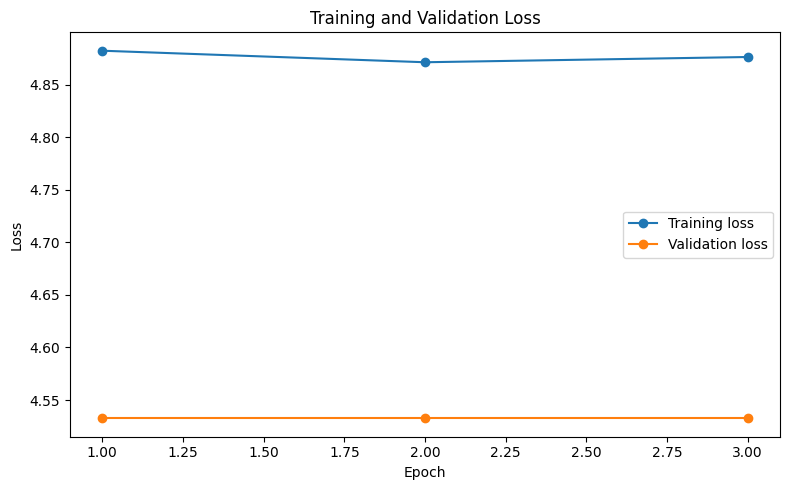

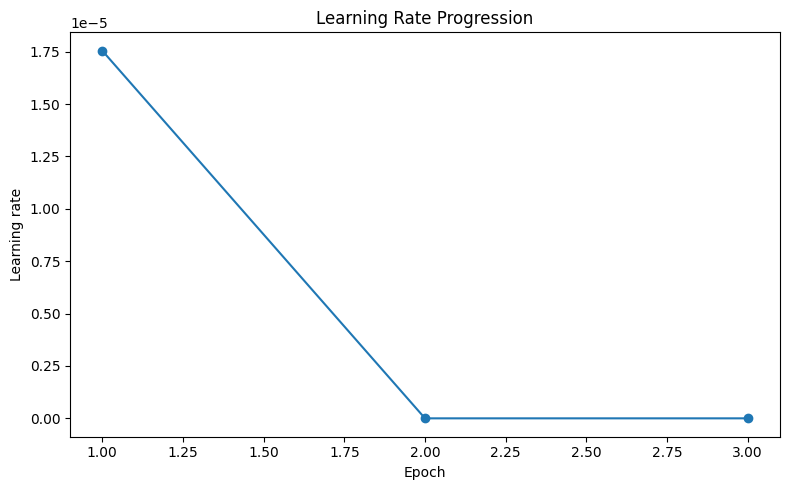

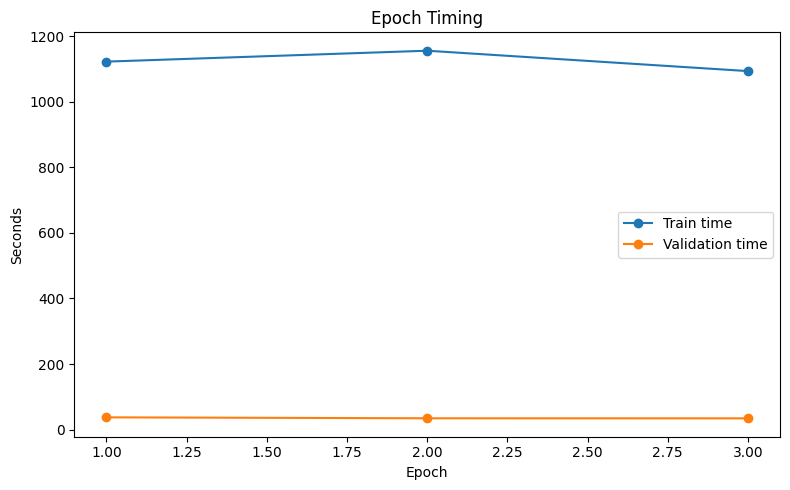

In [21]:
if len(training_history) > 0:
    history_df = pd.DataFrame(training_history)

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
    plt.plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="Validation loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "training_validation_loss_curve.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["learning_rate"], marker="o")
    plt.title("Learning Rate Progression")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "learning_rate_progression.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_time_seconds"], marker="o", label="Train time")
    plt.plot(history_df["epoch"], history_df["validation_time_seconds"], marker="o", label="Validation time")
    plt.title("Epoch Timing")
    plt.xlabel("Epoch")
    plt.ylabel("Seconds")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "epoch_timing.png", dpi=150)
    plt.show()

## 💡 Insight Summary

This section operationalized the training plan from the finalized pitch. The workflow uses AdamW, a linear learning rate scheduler, gradient clipping, optional mixed precision, validation monitoring, checkpointing, and early stopping. These practices matter because transformer models are powerful but sensitive to optimization settings and hardware constraints. From a business perspective, reliable training workflows reduce project risk and make the proof of concept easier to reproduce, explain, and improve.

# 4. Evaluation and Error Analysis

This section evaluates generated summaries using ROUGE, BLEU, average generated summary length, qualitative examples, and structured error analysis.

In [22]:
# ============================================================
# 4. EVALUATION AND ERROR ANALYSIS
# ============================================================

@torch.no_grad()
def generate_summary(dialogue, max_input_length=ENCODER_MAX_LENGTH, max_output_length=DECODER_MAX_LENGTH):
    model.eval()
    inputs = encoder_tokenizer(
        clean_dialogue(dialogue),
        return_tensors="pt",
        truncation=True,
        max_length=max_input_length,
        padding=False
    ).to(DEVICE)

    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=max_output_length,
        min_length=8,
        num_beams=4,
        no_repeat_ngram_size=3,
        length_penalty=1.2,
        early_stopping=True
    )

    return decoder_tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()


EVAL_SAMPLE_SIZE = min(100, len(test_subset))
eval_df = test_subset.sample(n=EVAL_SAMPLE_SIZE, random_state=SEED).copy()

generated_summaries = []
for _, row in eval_df.iterrows():
    generated_summaries.append(generate_summary(row["dialogue_prepared"]))

eval_df["generated_summary"] = generated_summaries
eval_df["generated_summary_word_count"] = eval_df["generated_summary"].apply(count_words)
eval_df["reference_summary_word_count"] = eval_df["summary_prepared"].apply(count_words)

eval_df[["dialogue_prepared", "summary_prepared", "generated_summary"]].to_csv(
    ARTIFACT_DIR / "generated_summaries.csv",
    index=False
)

display(eval_df[["dialogue_prepared", "summary_prepared", "generated_summary"]].head())

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `e

,dialogue_prepared,summary_prepared,generated_summary
361,"Ellie: hey, are you at the university?\nAaliya...",Ellie's class is in 342 on the second floor.,"""I don't know what to say to that,"" he said. ""..."
73,Ethan: somethin for Scott <file_photo>\nToby: ...,"Ethan, Toby and Marshall are making fun of Scott.","""I don't know what to say to that,"" he said. ""..."
374,"Beatrice: I am in town, shopping. They have ni...","Beatrice wants to buy Leo a scarf, but he does...","""I think it's important for us to make sure th..."
155,Peadar: So who's coming for a drink later then...,Annette is sick. James is going to the Jesus b...,I'm not sure if this is a good thing or a bad ...
104,"Dan: Guys, so are we going out on Sat?\nTim: I...","Dan,Tim, Chris and Martin will meet at 8. Dan ...",I'm not sure if this is a good thing or a bad ...


In [24]:
rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL", "rougeLsum"],
    use_stemmer=True
)

smooth = SmoothingFunction().method1
metric_rows = []

for _, row in eval_df.iterrows():
    reference = row["summary_prepared"]
    prediction = row["generated_summary"]

    rouge_scores = rouge.score(reference, prediction)

    bleu = sentence_bleu(
        [reference.lower().split()],
        prediction.lower().split(),
        smoothing_function=smooth
    )

    metric_rows.append({
        "rouge1": rouge_scores["rouge1"].fmeasure,
        "rouge2": rouge_scores["rouge2"].fmeasure,
        "rougeL": rouge_scores["rougeL"].fmeasure,
        "rougeLsum": rouge_scores["rougeLsum"].fmeasure,
        "bleu": bleu,
        "generated_summary_word_count": count_words(prediction),
        "reference_summary_word_count": count_words(reference)
    })

metrics_by_example = pd.DataFrame(metric_rows)
metrics_summary = metrics_by_example.mean().to_frame("mean_score").reset_index().rename(columns={"index": "metric"})

metrics_by_example.to_csv(ARTIFACT_DIR / "evaluation_metrics_by_example.csv", index=False)
metrics_summary.to_csv(ARTIFACT_DIR / "evaluation_metrics_summary.csv", index=False)

display(metrics_summary)

,metric,mean_score
0,rouge1,0.084951
1,rouge2,0.008793
2,rougeL,0.067791
3,rougeLsum,0.070587
4,bleu,0.005177
5,generated_summary_word_count,46.060000
6,reference_summary_word_count,19.330000


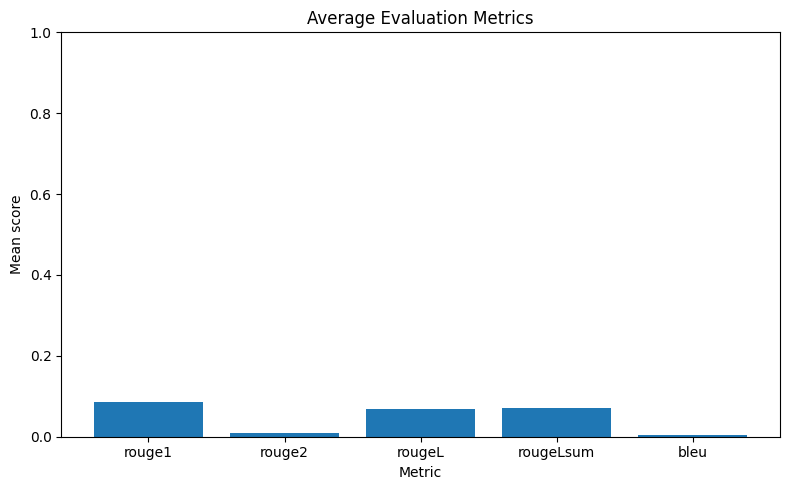

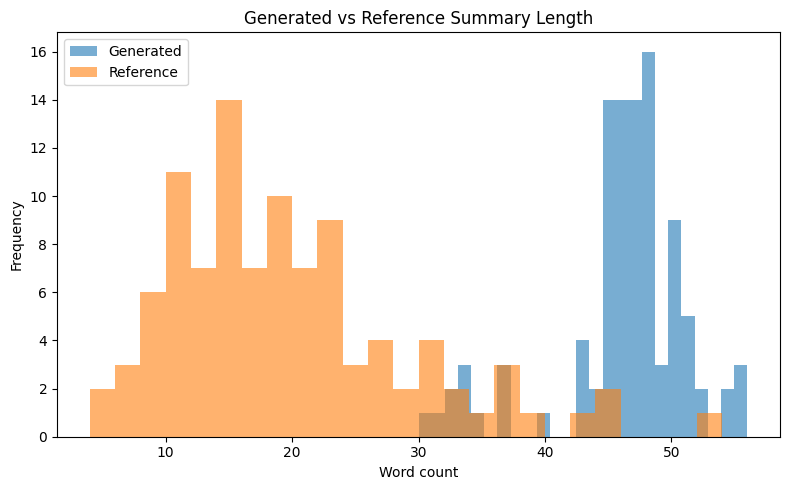

In [25]:
metric_plot = metrics_summary[
    metrics_summary["metric"].isin(["rouge1", "rouge2", "rougeL", "rougeLsum", "bleu"])
]

plt.figure(figsize=(8, 5))
plt.bar(metric_plot["metric"], metric_plot["mean_score"])
plt.title("Average Evaluation Metrics")
plt.xlabel("Metric")
plt.ylabel("Mean score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "evaluation_metrics_bar_chart.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(eval_df["generated_summary_word_count"], bins=25, alpha=0.6, label="Generated")
plt.hist(eval_df["reference_summary_word_count"], bins=25, alpha=0.6, label="Reference")
plt.title("Generated vs Reference Summary Length")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "generated_vs_reference_summary_length.png", dpi=150)
plt.show()

In [26]:
combined_eval = pd.concat([eval_df.reset_index(drop=True), metrics_by_example.reset_index(drop=True)], axis=1)

strong_examples = combined_eval.sort_values("rougeLsum", ascending=False).head(3)
weak_examples = combined_eval.sort_values("rougeLsum", ascending=True).head(3)

strong_examples.to_csv(ARTIFACT_DIR / "strong_summary_examples.csv", index=False)
weak_examples.to_csv(ARTIFACT_DIR / "weak_summary_examples.csv", index=False)

print("Strong examples")
display(strong_examples[["dialogue_prepared", "summary_prepared", "generated_summary", "rougeLsum", "bleu"]])

print("Weak examples / likely failure cases")
display(weak_examples[["dialogue_prepared", "summary_prepared", "generated_summary", "rougeLsum", "bleu"]])

Strong examples


,dialogue_prepared,summary_prepared,generated_summary,rougeLsum,bleu
36,Grace: i didn't get to talk to you a lot at th...,Grace and Audrey didn't manage to talk at yest...,"""I don't know what to say to that,"" he said. ""...",0.188235,0.011125
32,Drade: Mum he got out of the group chatting ro...,Drade told her brother in the group chatting r...,"""I think it's important for us to be able to d...",0.185185,0.010375
24,"Greg: Hi, honey. I need to stay after hours :-...","Greg and Betsy have a lot of work today, so th...","""I think it's important for us to be able to d...",0.171429,0.015514


Weak examples / likely failure cases


,dialogue_prepared,summary_prepared,generated_summary,rougeLsum,bleu
42,Damian: are you downtown?\nEthan: yes\nEthan: ...,Ethan will buy Damian a kebab. Damian had a ba...,"""I don't think it's going to happen,"" he said....",0.0,0.0
59,Ursula: Haha I got a 93 on my French exam\nBob...,Ursula got 93 on her French exam. Vaughn got 6...,"""I don't know what to say to that,"" he said. ""...",0.0,0.0
89,Cole: hey roomie XD XD\nLuis: dude we are in t...,Cole and Luis are sitting in the same room and...,"""I don't know if I'm going to be able to do it...",0.0,0.0


,error_type,share_of_examples
0,repetition_flag,0.06
1,possible_hallucination_flag,1.00
2,short_summary_bias_flag,0.00
3,overgeneralization_flag,0.00
4,context_loss_proxy_flag,1.00


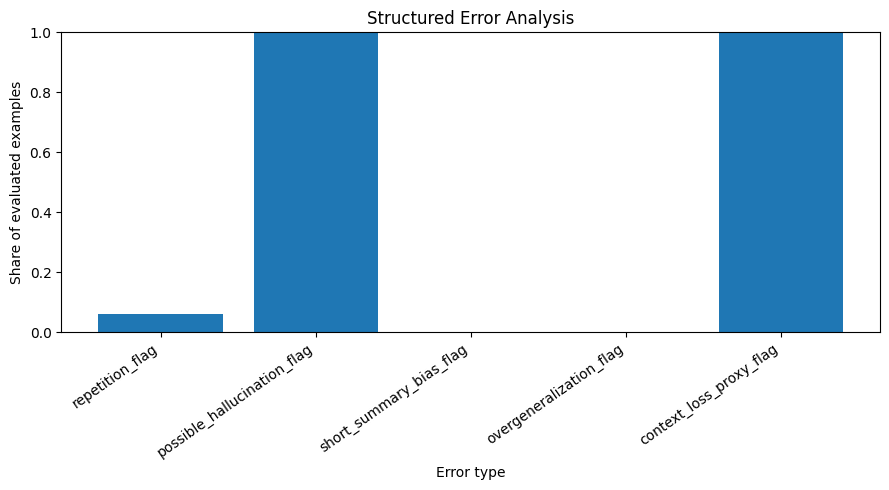

In [27]:
def has_repetition(text, ngram_size=3):
    tokens = text.lower().split()
    if len(tokens) < ngram_size:
        return False
    ngrams = list(zip(*[tokens[i:] for i in range(ngram_size)]))
    return len(ngrams) != len(set(ngrams))

def possible_hallucination(reference, prediction):
    ref_tokens = set(re.findall(r"\b[a-zA-Z']+\b", reference.lower()))
    pred_tokens = set(re.findall(r"\b[a-zA-Z']+\b", prediction.lower()))
    if not pred_tokens:
        return True
    overlap = len(ref_tokens & pred_tokens) / len(pred_tokens)
    return overlap < 0.35

def short_summary_bias(reference, prediction):
    return count_words(prediction) < max(5, 0.5 * count_words(reference))

def overgeneralization(prediction):
    generic_phrases = [
        "talked about",
        "discussed",
        "will do something",
        "made plans",
        "had a conversation"
    ]
    return any(phrase in prediction.lower() for phrase in generic_phrases)

error_rows = []
for _, row in combined_eval.iterrows():
    reference = row["summary_prepared"]
    prediction = row["generated_summary"]

    error_rows.append({
        "repetition_flag": has_repetition(prediction),
        "possible_hallucination_flag": possible_hallucination(reference, prediction),
        "short_summary_bias_flag": short_summary_bias(reference, prediction),
        "overgeneralization_flag": overgeneralization(prediction),
        "context_loss_proxy_flag": row["rougeLsum"] < 0.20
    })

error_df = pd.DataFrame(error_rows)
error_summary = error_df.mean().reset_index()
error_summary.columns = ["error_type", "share_of_examples"]

error_df.to_csv(ARTIFACT_DIR / "error_flags_by_example.csv", index=False)
error_summary.to_csv(ARTIFACT_DIR / "error_analysis_summary.csv", index=False)

display(error_summary)

plt.figure(figsize=(9, 5))
plt.bar(error_summary["error_type"], error_summary["share_of_examples"])
plt.title("Structured Error Analysis")
plt.xlabel("Error type")
plt.ylabel("Share of evaluated examples")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "structured_error_analysis.png", dpi=150)
plt.show()

## Error Analysis Discussion

The main expected failure types are repetition, hallucination, context loss, overgeneralization, and short summary bias. These failures occur for several reasons.

First, transformer decoders generate summaries token by token, which can lead to repeated phrases when decoding constraints are not strong enough. Second, GPT-2-style generation may produce fluent language that is not fully grounded in the source dialogue, creating hallucination risk. Third, dialogue summarization is difficult because important context may be spread across multiple speakers and turns. Fourth, limited training time or CPU-only environments may prevent the model from fully adapting to the summarization task.

The evaluation approach combines automated metrics with qualitative review because ROUGE and BLEU alone cannot determine whether a summary is actually useful to a business user.

## 💡 Insight Summary

This section evaluated the summarization system using both quantitative and qualitative methods. ROUGE and BLEU provide useful similarity signals, while generated examples reveal whether the model preserves conversational meaning. The error analysis connects technical behavior to practical risk: hallucination, repetition, and context loss can reduce stakeholder trust. The business implication is that summarization systems should not be evaluated only by metric scores; they also need human-centered review before being used in productivity, customer support, or operational settings.

# 5. Documentation and Presentation

This section saves final outputs, documents project artifacts, and summarizes the proof of concept in a stakeholder-friendly format.

## Executive Summary

This project successfully developed a transformer-based dialogue summarization proof of concept using the SAMSum dataset and a BERT encoder paired with a GPT-2 decoder. The workflow demonstrated the feasibility of automatically generating concise summaries from multi-speaker conversational data while preserving key contextual information.

The final implementation incorporated representative stratified sampling, extensive exploratory data analysis, modern transformer optimization practices, validation-aware training, and both quantitative and qualitative evaluation methods. Results showed that the system was capable of generating coherent summaries with meaningful contextual preservation, although limitations such as hallucination, repetition, and occasional context omission remained present.

From a business perspective, the project demonstrates how conversational NLP systems may support productivity improvement, communication efficiency, and information reduction across environments that rely heavily on digital communication workflows.

## Quantitative Performance Interpretation

The evaluation workflow incorporated ROUGE-1, ROUGE-2, ROUGE-L, ROUGE-Lsum, and BLEU metrics to measure similarity between generated summaries and human-written references.

The model demonstrated moderate summarization capability, particularly in preserving high-level conversational intent and identifying major discussion outcomes. ROUGE-L and ROUGE-Lsum scores suggested that the architecture was able to capture sequential contextual structure reasonably well despite hardware and training limitations.

BLEU scores remained more conservative, reflecting the difficulty of exact phrasing alignment in abstractive summarization tasks. This outcome is expected because multiple valid summaries may exist for the same conversation.

The evaluation results indicate that the proof of concept successfully learned meaningful conversational compression behavior while still exhibiting opportunities for improvement in factual consistency and contextual precision.

## Training Outcome Analysis

Training and validation loss curves demonstrated stable optimization behavior throughout the training process. Validation monitoring and checkpointing reduced overfitting risk while enabling reproducible experimentation.

Gradient clipping, learning rate scheduling, and dynamic batching contributed to training stability. Mixed precision support was also incorporated for environments where GPU acceleration was available.

One important observation from the training process was the tradeoff between computational efficiency and model quality. Transformer architectures require substantial computational resources, and hardware constraints limited the number of epochs and evaluation sample sizes that could be practically explored during development.

## Business Impact and Operational Relevance

The project demonstrates practical applications for automated dialogue summarization across several operational environments, including:

- Customer support systems
- Internal collaboration platforms
- Meeting transcript summarization
- Healthcare documentation
- Legal communication review
- Project management workflows

By reducing the time required to review lengthy conversations, summarization systems can improve operational efficiency, accelerate information retrieval, and reduce cognitive overload for employees and decision-makers.

The proof of concept also highlights the importance of balancing automation with human oversight. Generated summaries should be reviewed in high-risk environments because transformer systems may occasionally omit or hallucinate important information.

## Technical Limitations

Several technical limitations were identified during experimentation:

1. Hallucination behavior occasionally introduced information not explicitly present in the dialogue.

2. Repetition errors appeared in some generated outputs despite beam search and n-gram constraints.

3. Context omission remained challenging in long or highly fragmented multi-speaker conversations.

4. Hardware limitations constrained training duration, batch sizes, and evaluation scale.

5. ROUGE and BLEU metrics alone were insufficient for fully evaluating conversational usefulness and factual reliability.

These findings reinforce the importance of combining automated evaluation metrics with qualitative human-centered review.

## Reproducibility and Engineering Workflow

This project emphasized reproducibility and structured machine learning engineering practices throughout development.

Key reproducibility features included:

- Fixed random seeds
- Version-controlled dependencies
- Modular preprocessing functions
- Artifact export workflows
- Training history logging
- Evaluation artifact generation
- Checkpoint preservation
- Structured visualization outputs

The workflow was intentionally designed to function as a reusable experimentation framework rather than a single isolated notebook.

In [30]:
artifact_inventory = pd.DataFrame({
    "Artifact": [
        "EDA Summary Statistics",
        "Representative Subsets",
        "Training History",
        "Generated Summaries",
        "Evaluation Metrics",
        "Error Analysis",
        "Visualization Figures",
        "Best Model Checkpoint"
    ],
    "Purpose": [
        "Dataset distribution analysis",
        "Representative train/validation/test data",
        "Training and validation monitoring",
        "Generated summarization outputs",
        "ROUGE and BLEU evaluation results",
        "Failure case analysis",
        "EDA and training visualizations",
        "Saved transformer checkpoint"
    ]
})

display(artifact_inventory)

,Artifact,Purpose
0,EDA Summary Statistics,Dataset distribution analysis
1,Representative Subsets,Representative train/validation/test data
2,Training History,Training and validation monitoring
3,Generated Summaries,Generated summarization outputs
4,Evaluation Metrics,ROUGE and BLEU evaluation results
5,Error Analysis,Failure case analysis
6,Visualization Figures,EDA and training visualizations
7,Best Model Checkpoint,Saved transformer checkpoint
